# 8 km hgrid comparison: old vs no-bipolar_lower_lat

In [2]:
import json
import os

import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import netCDF4 as nc
import numpy as np
import pandas as pd

OLD_PATH = '/g/data/tm70/ek4684/8km_grid_input_files/ocean_hgrid_bipolar_lower_lat_65N.nc'
NEW_PATH = '/g/data/tm70/ek4684/8km_grid_input_files/ocean_hgrid.nc'
OUTDIR = '/g/data/tm70/ek4684/8km_grid_input_files/grid_comparison_no_bipolar_lower_lat'
os.makedirs(OUTDIR, exist_ok=True)

OLD_LABEL = 'Old (--bipolar_lower_lat 65)'
NEW_LABEL = 'New (no --bipolar_lower_lat)'


def savefig(fig, name):
    fig.savefig(os.path.join(OUTDIR, name), dpi=150, bbox_inches='tight')


old = nc.Dataset(OLD_PATH)
new = nc.Dataset(NEW_PATH)


## Dimensions and lon/lat range

In [3]:
def dims(ds):
    return {d: len(ds.dimensions[d]) for d in ('nyp', 'nxp', 'ny', 'nx')}


def lonlat_range(ds):
    y, x = ds.variables['y'], ds.variables['x']
    return {'lat_min': float(y[:].min()), 'lat_max': float(y[:].max()),
            'lon_min': float(x[:].min()), 'lon_max': float(x[:].max())}


rows = []
for label, ds in [(OLD_LABEL, old), (NEW_LABEL, new)]:
    rows.append({'grid': label, **dims(ds), **lonlat_range(ds)})
meta_df = pd.DataFrame(rows).set_index('grid')
meta_df.loc['old - new'] = meta_df.loc[OLD_LABEL] - meta_df.loc[NEW_LABEL]

for label in [OLD_LABEL, NEW_LABEL]:
    r = meta_df.loc[label]
    print(f'{label}: nyp={r.nyp:.0f} nxp={r.nxp:.0f} ny={r.ny:.0f} nx={r.nx:.0f} '
          f'lat=[{r.lat_min:.3f},{r.lat_max:.3f}] lon=[{r.lon_min:.3f},{r.lon_max:.3f}]')


Old (--bipolar_lower_lat 65): nyp=7345 nxp=8641 ny=7344 nx=8640 lat=[-86.500,90.000] lon=[-280.000,80.000]
New (no --bipolar_lower_lat): nyp=7345 nxp=8641 ny=7344 nx=8640 lat=[-86.500,90.000] lon=[-280.000,80.000]


## dx, dy, area statistics

In [4]:
def approx_tpoint(ds, varname):
    return ds.variables[varname][1::2, 1::2]


def stats_row(arr, label, varname):
    flat = np.asarray(arr).ravel()
    return {
        'grid': label, 'field': varname,
        'min': flat.min(), 'max': flat.max(), 'mean': flat.mean(),
        'p01': np.percentile(flat, 1), 'p50': np.percentile(flat, 50), 'p99': np.percentile(flat, 99),
        'argmin_yx': np.unravel_index(np.argmin(arr), arr.shape),
        'argmax_yx': np.unravel_index(np.argmax(arr), arr.shape),
    }


stat_rows = []
tpoint_cache = {}
for varname in ['dx', 'dy', 'area']:
    for label, ds in [(OLD_LABEL, old), (NEW_LABEL, new)]:
        arr = approx_tpoint(ds, varname)
        tpoint_cache[(label, varname)] = arr
        stat_rows.append(stats_row(arr, label, varname))
stats_df = pd.DataFrame(stat_rows).set_index(['field', 'grid'])

for (field, label), r in stats_df.iterrows():
    print(f'{field:5s} {label}: min={r["min"]:.3f} max={r["max"]:.3f} mean={r["mean"]:.3f} '
          f'p01={r.p01:.3f} p50={r.p50:.3f} p99={r.p99:.3f} argmin={r.argmin_yx} argmax={r.argmax_yx}')


dx    Old (--bipolar_lower_lat 65): min=283.715 max=4633.122 mean=2521.910 p01=346.328 p50=2280.203 p99=4631.535 argmin=(0, 0) argmax=(1927, 1)
dx    New (no --bipolar_lower_lat): min=283.715 max=4633.122 mean=2522.016 p01=346.328 p50=2280.203 p99=4631.535 argmin=(0, 0) argmax=(1927, 0)
dy    Old (--bipolar_lower_lat 65): min=1.427 max=4633.122 mean=2554.761 p01=225.178 p50=2280.203 p99=4631.490 argmin=(2963, 0) argmax=(1927, 0)
dy    New (no --bipolar_lower_lat): min=1.428 max=4633.122 mean=2554.856 p01=225.254 p50=2280.203 p99=4631.490 argmin=(2963, 0) argmax=(1927, 0)
area  Old (--bipolar_lower_lat 65): min=1397.128 max=21465815.160 mean=8030983.381 p01=353094.569 p50=5199328.074 p99=21450701.144 argmin=(2963, 2159) argmax=(1927, 1)
area  New (no --bipolar_lower_lat): min=1398.125 max=21465816.000 mean=8031256.617 p01=353094.562 p50=5199328.000 p99=21450702.000 argmin=(2963, 2159) argmax=(1927, 0)


In [5]:
diff_rows = []
for varname in ['dx', 'dy', 'area']:
    old_arr = np.asarray(tpoint_cache[(OLD_LABEL, varname)])
    new_arr = np.asarray(tpoint_cache[(NEW_LABEL, varname)])
    shape_match = old_arr.shape == new_arr.shape
    row = {'field': varname, 'shape_match': shape_match}
    if shape_match:
        d = old_arr - new_arr
        row.update(max_abs_diff=np.abs(d).max(), mean_diff=d.mean(), rms_diff=np.sqrt((d**2).mean()))
    diff_rows.append(row)
diff_df = pd.DataFrame(diff_rows).set_index('field')

for field, r in diff_df.iterrows():
    if r.shape_match:
        print(f'{field:5s} old-new: max_abs={r.max_abs_diff:.4f} mean={r.mean_diff:.4f} rms={r.rms_diff:.4f}')
    else:
        print(f'{field:5s} shapes differ, no direct diff')


dx    old-new: max_abs=0.6754 mean=-0.1054 rms=0.2428
dy    old-new: max_abs=0.7227 mean=-0.0952 rms=0.2359
area  old-new: max_abs=2737.1687 mean=-273.2360 rms=670.6060


## Maps: dx, dy, area, angle_dx

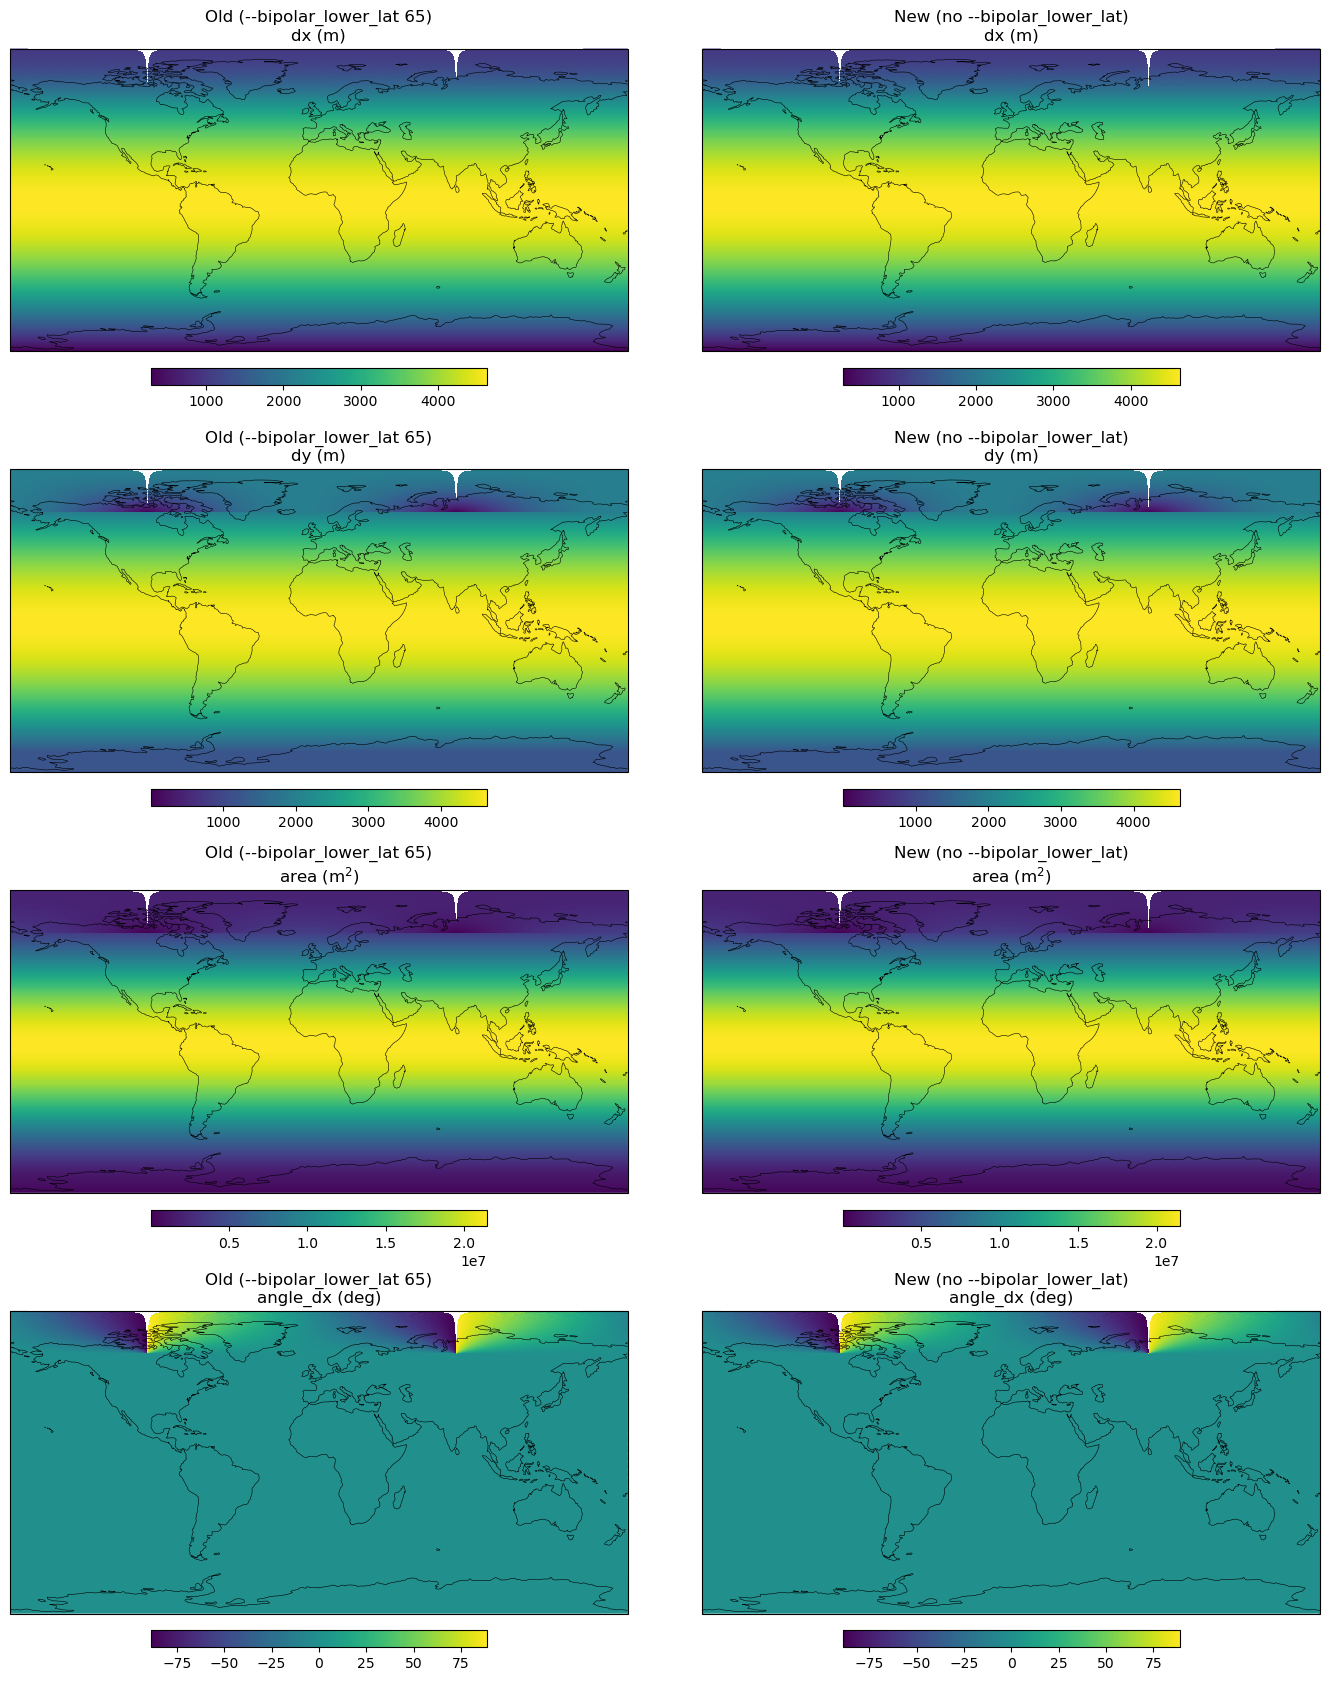

In [6]:
STRIDE = 8
map_vars = ['dx', 'dy', 'area', 'angle_dx']
map_titles = ['dx (m)', 'dy (m)', 'area (m$^2$)', 'angle_dx (deg)']

fig, axes = plt.subplots(len(map_vars), 2, figsize=(14, 4.2 * len(map_vars)),
                          subplot_kw={'projection': ccrs.PlateCarree()})

for i, (varname, title) in enumerate(zip(map_vars, map_titles)):
    old_arr = old.variables[varname][1::2, 1::2][::STRIDE, ::STRIDE]
    new_arr = new.variables[varname][1::2, 1::2][::STRIDE, ::STRIDE]
    lon = old.variables['x'][1::2, 1::2][::STRIDE, ::STRIDE]
    lat = old.variables['y'][1::2, 1::2][::STRIDE, ::STRIDE]
    lon_new = new.variables['x'][1::2, 1::2][::STRIDE, ::STRIDE]
    lat_new = new.variables['y'][1::2, 1::2][::STRIDE, ::STRIDE]

    vmin = min(np.nanmin(old_arr), np.nanmin(new_arr))
    vmax = max(np.nanmax(old_arr), np.nanmax(new_arr))

    ax = axes[i, 0]
    p0 = ax.pcolormesh(lon, lat, old_arr, transform=ccrs.PlateCarree(), vmin=vmin, vmax=vmax, cmap='viridis')
    ax.coastlines(linewidth=0.4)
    ax.set_title(f'{OLD_LABEL}\n{title}')
    fig.colorbar(p0, ax=ax, orientation='horizontal', fraction=0.05, pad=0.05)

    ax = axes[i, 1]
    p1 = ax.pcolormesh(lon_new, lat_new, new_arr, transform=ccrs.PlateCarree(), vmin=vmin, vmax=vmax, cmap='viridis')
    ax.coastlines(linewidth=0.4)
    ax.set_title(f'{NEW_LABEL}\n{title}')
    fig.colorbar(p1, ax=ax, orientation='horizontal', fraction=0.05, pad=0.05)

plt.tight_layout()
savefig(fig, '01_maps_dx_dy_area_angle.png')
plt.show()


## Zoom: area near the Mercator-bipolar join (~65N)

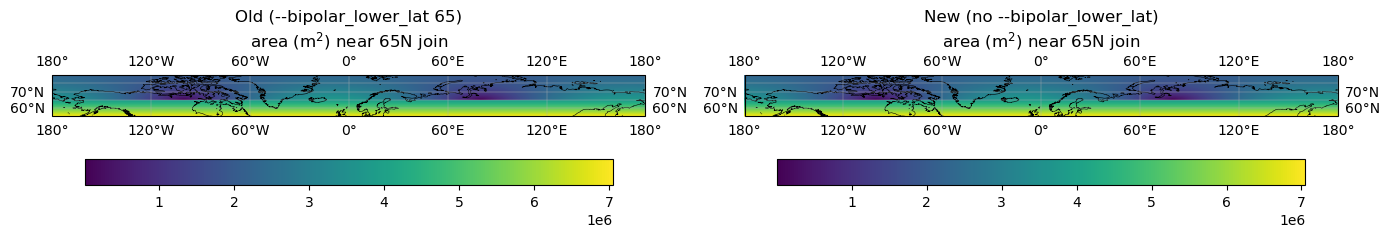

In [7]:
ZOOM_LAT_LO, ZOOM_LAT_HI = 55.0, 80.0
ZOOM_STRIDE = 2

def zoom_tpoint(ds, varname, lat_lo, lat_hi, stride):
    lat_col0 = ds.variables['y'][1::2, 1::2][:, 0]
    rows = np.where((lat_col0 >= lat_lo) & (lat_col0 <= lat_hi))[0]
    r0, r1 = rows.min(), rows.max() + 1
    lon_z = ds.variables['x'][1::2, 1::2][r0:r1:stride, ::stride]
    lat_z = ds.variables['y'][1::2, 1::2][r0:r1:stride, ::stride]
    val_z = ds.variables[varname][1::2, 1::2][r0:r1:stride, ::stride]
    return lon_z, lat_z, val_z

lon_old_z, lat_old_z, area_old_z = zoom_tpoint(old, 'area', ZOOM_LAT_LO, ZOOM_LAT_HI, ZOOM_STRIDE)
lon_new_z, lat_new_z, area_new_z = zoom_tpoint(new, 'area', ZOOM_LAT_LO, ZOOM_LAT_HI, ZOOM_STRIDE)

vmin = min(np.nanmin(area_old_z), np.nanmin(area_new_z))
vmax = max(np.nanmax(area_old_z), np.nanmax(area_new_z))

fig, axes = plt.subplots(1, 2, figsize=(14, 6), subplot_kw={'projection': ccrs.PlateCarree()})

ax = axes[0]
p0 = ax.pcolormesh(lon_old_z, lat_old_z, area_old_z, transform=ccrs.PlateCarree(), vmin=vmin, vmax=vmax, cmap='viridis')
ax.coastlines(linewidth=0.4)
ax.set_extent([-180, 180, ZOOM_LAT_LO, ZOOM_LAT_HI], crs=ccrs.PlateCarree())
ax.gridlines(draw_labels=True, linewidth=0.3)
ax.set_title(f'{OLD_LABEL}\narea (m$^2$) near 65N join')
fig.colorbar(p0, ax=ax, orientation='horizontal', fraction=0.05, pad=0.08)

ax = axes[1]
p1 = ax.pcolormesh(lon_new_z, lat_new_z, area_new_z, transform=ccrs.PlateCarree(), vmin=vmin, vmax=vmax, cmap='viridis')
ax.coastlines(linewidth=0.4)
ax.set_extent([-180, 180, ZOOM_LAT_LO, ZOOM_LAT_HI], crs=ccrs.PlateCarree())
ax.gridlines(draw_labels=True, linewidth=0.3)
ax.set_title(f'{NEW_LABEL}\narea (m$^2$) near 65N join')
fig.colorbar(p1, ax=ax, orientation='horizontal', fraction=0.05, pad=0.08)

plt.tight_layout()
savefig(fig, '01b_area_zoom_65N_join.png')
plt.show()


## Cumulative distribution of dy

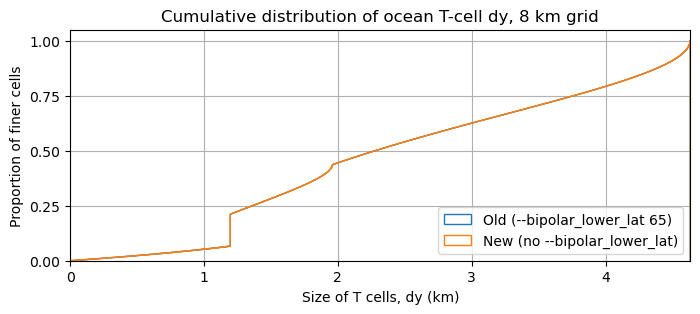

In [8]:
dy_old = np.ma.ravel(tpoint_cache[(OLD_LABEL, 'dy')]) / 1000.0
dy_new = np.ma.ravel(tpoint_cache[(NEW_LABEL, 'dy')]) / 1000.0
xmax = max(dy_old.max(), dy_new.max())

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(dy_old, bins=1000, range=(0, xmax), density=True, histtype='step', cumulative=True, label=OLD_LABEL)
ax.hist(dy_new, bins=1000, range=(0, xmax), density=True, histtype='step', cumulative=True, label=NEW_LABEL)
ax.set_xlim(0, xmax)
ax.set_yticks([0, .25, .5, .75, 1])
ax.grid()
ax.set_xlabel('Size of T cells, dy (km)')
ax.set_ylabel('Proportion of finer cells')
ax.set_title('Cumulative distribution of ocean T-cell dy, 8 km grid')
ax.legend(loc='lower right')
savefig(fig, '02_dy_cumulative_distribution.png')
plt.show()


## Latitudinal dependence: dy and aspect ratio

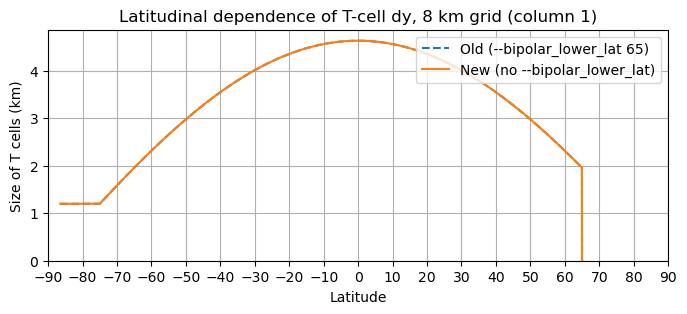

In [9]:
col = 1
lat_old = old.variables['y'][1::2, 1::2][:, col]
lat_new = new.variables['y'][1::2, 1::2][:, col]
dy_old_col = old.variables['dy'][1::2, 1::2][:, col] / 1000.0
dy_new_col = new.variables['dy'][1::2, 1::2][:, col] / 1000.0

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(lat_old, dy_old_col, label=OLD_LABEL, linestyle='--')
ax.plot(lat_new, dy_new_col, label=NEW_LABEL, linestyle='-')
ax.set_ylim(bottom=0)
ax.set_xlim(-90, 90)
ax.set_xticks(range(-90, 91, 10))
ax.set_ylabel('Size of T cells (km)')
ax.set_xlabel('Latitude')
ax.set_title(f'Latitudinal dependence of T-cell dy, 8 km grid (column {col})')
ax.legend(loc='upper right')
ax.grid()
savefig(fig, '03_dy_vs_latitude.png')
plt.show()


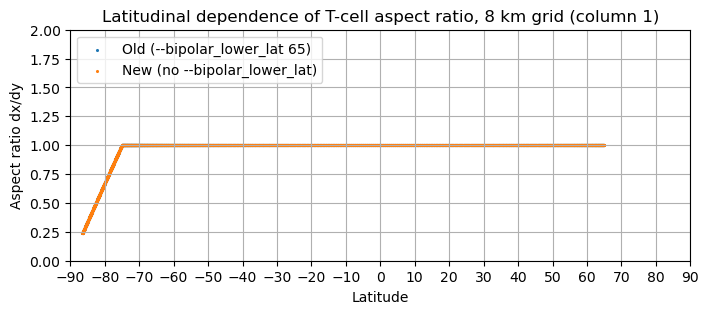

In [10]:
dx_old_col = old.variables['dx'][1::2, 1::2][:, col]
dx_new_col = new.variables['dx'][1::2, 1::2][:, col]
dy_old_col_m = old.variables['dy'][1::2, 1::2][:, col]
dy_new_col_m = new.variables['dy'][1::2, 1::2][:, col]

fig, ax = plt.subplots(figsize=(8, 3))
ax.scatter(lat_old, dx_old_col / dy_old_col_m, s=1.5, label=OLD_LABEL)
ax.scatter(lat_new, dx_new_col / dy_new_col_m, s=1.5, label=NEW_LABEL)
ax.set_ylim(0, 2)
ax.set_xlim(-90, 90)
ax.set_xticks(range(-90, 91, 10))
ax.set_ylabel('Aspect ratio dx/dy')
ax.set_xlabel('Latitude')
ax.set_title(f'Latitudinal dependence of T-cell aspect ratio, 8 km grid (column {col})')
ax.legend(loc='upper left')
ax.grid()
savefig(fig, '04_aspect_ratio_vs_latitude.png')
plt.show()


## Tripolar grid overview

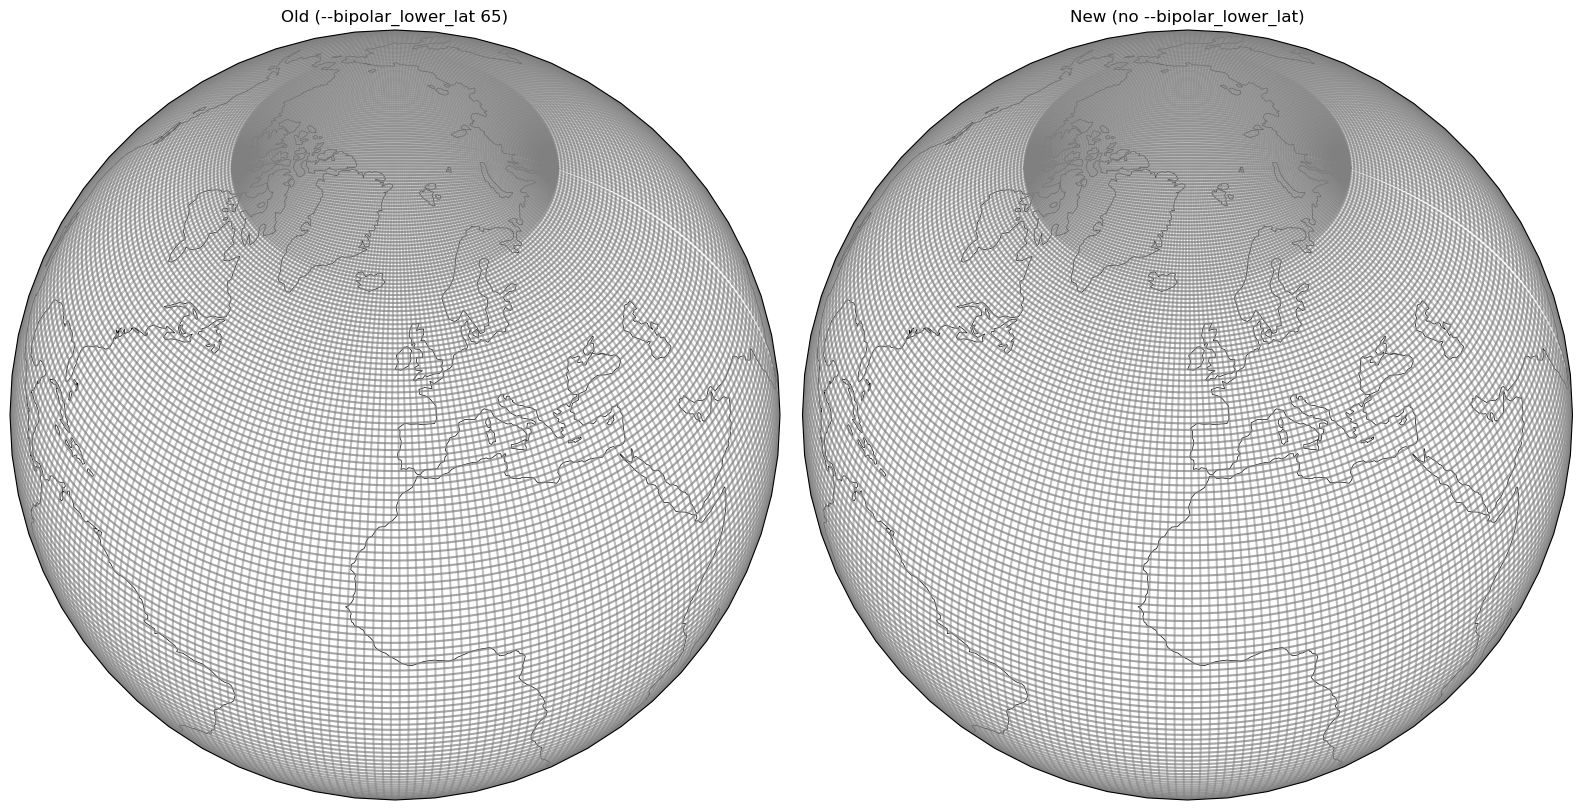

In [11]:
SUB = 32
fig, axes = plt.subplots(1, 2, figsize=(16, 8), subplot_kw={'projection': ccrs.Orthographic(-10, 45)})

for ax, ds, label in [(axes[0], old, OLD_LABEL), (axes[1], new, NEW_LABEL)]:
    sx = ds.variables['x'][1::SUB, 1::SUB]
    sy = ds.variables['y'][1::SUB, 1::SUB]
    ax.set_global()
    ax.coastlines(linewidth=0.5)
    ax.plot(sx, sy, transform=ccrs.PlateCarree(), color='grey', alpha=0.5)
    ax.plot(sx.transpose(), sy.transpose(), transform=ccrs.PlateCarree(), color='grey', alpha=0.7)
    ax.set_title(label)

plt.tight_layout()
savefig(fig, '05_tripolar_overview.png')
plt.show()


## Mercator-bipolar join diagnostics

In [12]:
def find_join_row(ds, lat_lo=55.0, lat_hi=80.0, tol=1e-6):
    y = ds.variables['y'][:]
    candidates = np.where((y[:, 0] > lat_lo) & (y[:, 0] < lat_hi))[0]
    row_std = y[candidates, :].std(axis=1)
    return candidates[np.where(row_std > tol)[0][0]]


j_old = find_join_row(old)
j_new = find_join_row(new)
print(f'{OLD_LABEL}: join row j={j_old}, y[j,0]={old.variables["y"][j_old, 0]:.6f}, nyp={old.dimensions["nyp"].size}')
print(f'{NEW_LABEL}: join row j={j_new}, y[j,0]={new.variables["y"][j_new, 0]:.6f}, nyp={new.dimensions["nyp"].size}')

OFFSET_LO, OFFSET_HI = -8, 10
offsets = np.arange(OFFSET_LO, OFFSET_HI + 1)


Old (--bipolar_lower_lat 65): join row j=5927, y[j,0]=65.000000, nyp=7345
New (no --bipolar_lower_lat): join row j=5927, y[j,0]=64.990784, nyp=7345


### Supergrid latitude y at the join

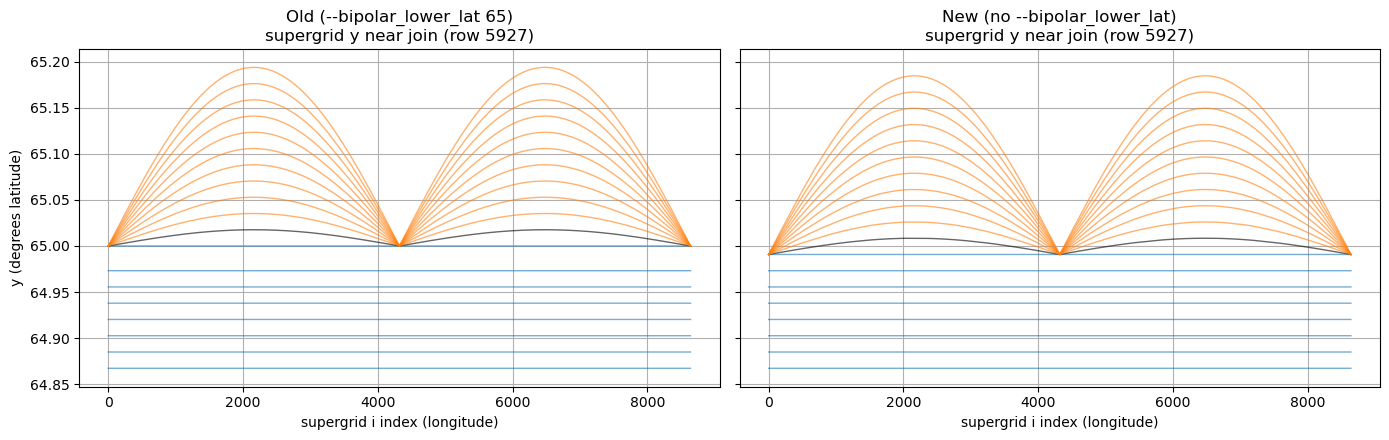

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)

ymin, ymax = np.inf, -np.inf
for ax, ds, j0, label in [(axes[0], old, j_old, OLD_LABEL), (axes[1], new, j_new, NEW_LABEL)]:
    for off in offsets:
        yline = ds.variables['y'][j0 + off, :]
        ax.plot(yline, color='C0' if off < 0 else ('k' if off == 0 else 'C1'), alpha=0.6, linewidth=1)
        ymin, ymax = min(ymin, yline.min()), max(ymax, yline.max())
    ax.set_title(f'{label}\nsupergrid y near join (row {j0})')
    ax.set_xlabel('supergrid i index (longitude)')
    ax.grid()

axes[0].set_ylabel('y (degrees latitude)')
for ax in axes:
    ax.set_ylim(ymin - 0.02, ymax + 0.02)

plt.tight_layout()
savefig(fig, '06_join_supergrid_latitude.png')
plt.show()


### Meridional latitude increment y[j,:] - y[j-1,:] (degrees)

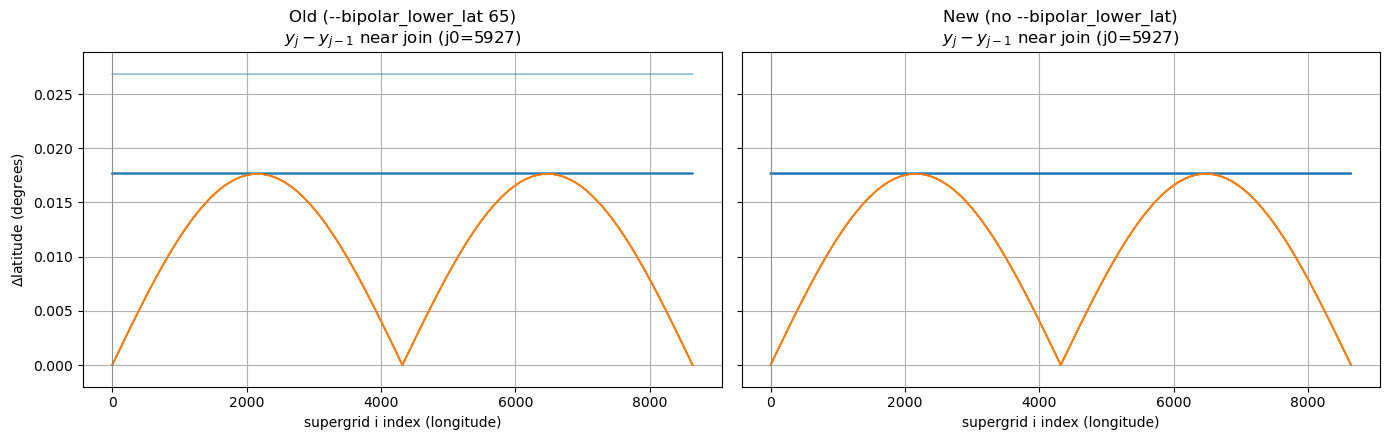

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)

inc_min, inc_max = np.inf, -np.inf
increments = {}
for ax, ds, j0, label in [(axes[0], old, j_old, OLD_LABEL), (axes[1], new, j_new, NEW_LABEL)]:
    incs = {}
    for off in offsets:
        j = j0 + off
        inc = ds.variables['y'][j, :] - ds.variables['y'][j - 1, :]
        incs[off] = inc
        ax.plot(inc, color='C0' if off < 0 else ('k' if off == 0 else 'C1'), alpha=0.6, linewidth=1)
        inc_min, inc_max = min(inc_min, inc.min()), max(inc_max, inc.max())
    increments[label] = incs
    ax.axvline(0, color='grey', linewidth=0.5)
    ax.set_title(f'{label}\n$y_j - y_{{j-1}}$ near join (j0={j0})')
    ax.set_xlabel('supergrid i index (longitude)')
    ax.grid()

axes[0].set_ylabel('$\\Delta$latitude (degrees)')
for ax in axes:
    ax.set_ylim(inc_min - 0.002, inc_max + 0.002)

plt.tight_layout()
savefig(fig, '07_join_latitude_increment.png')
plt.show()


### y[j,:] - y[j-1,:] as a 2D image, matched colour limits

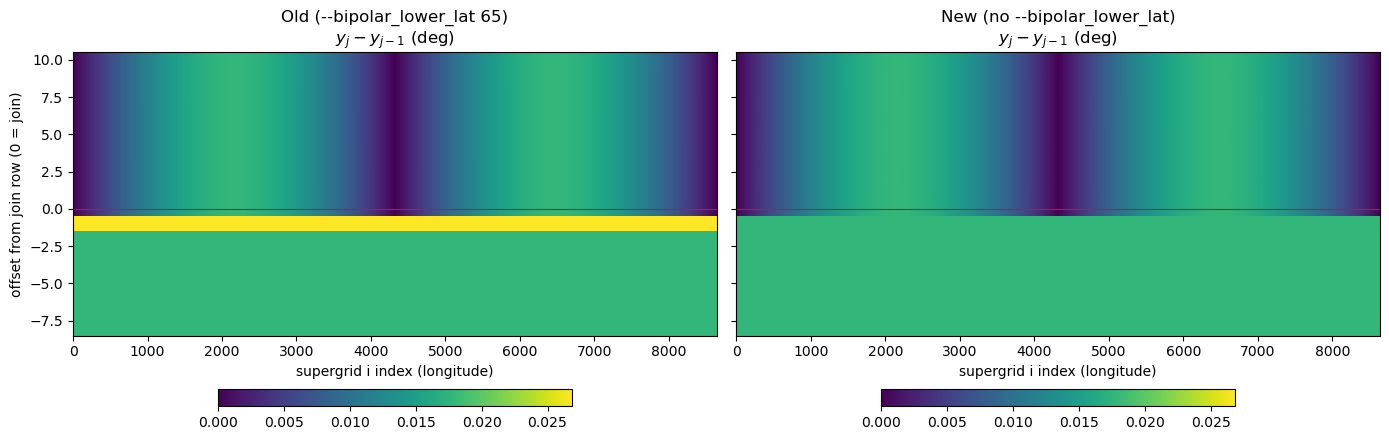

In [15]:
inc_img_old = np.array([increments[OLD_LABEL][off] for off in offsets])
inc_img_new = np.array([increments[NEW_LABEL][off] for off in offsets])
inc_img_vmin = min(inc_img_old.min(), inc_img_new.min())
inc_img_vmax = max(inc_img_old.max(), inc_img_new.max())

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)
for ax, img, label in [(axes[0], inc_img_old, OLD_LABEL), (axes[1], inc_img_new, NEW_LABEL)]:
    im = ax.pcolormesh(np.arange(img.shape[1]), offsets, img, vmin=inc_img_vmin, vmax=inc_img_vmax,
                        cmap='viridis', shading='auto')
    ax.axhline(0, color='r', linewidth=0.8)
    ax.set_title(f'{label}\n$y_j - y_{{j-1}}$ (deg)')
    ax.set_xlabel('supergrid i index (longitude)')
    fig.colorbar(im, ax=ax, orientation='horizontal', fraction=0.05, pad=0.15)

axes[0].set_ylabel('offset from join row (0 = join)')
plt.tight_layout()
savefig(fig, '07b_join_latitude_increment_2D.png')
plt.show()


### Native dy (metres) over the same join-region rows

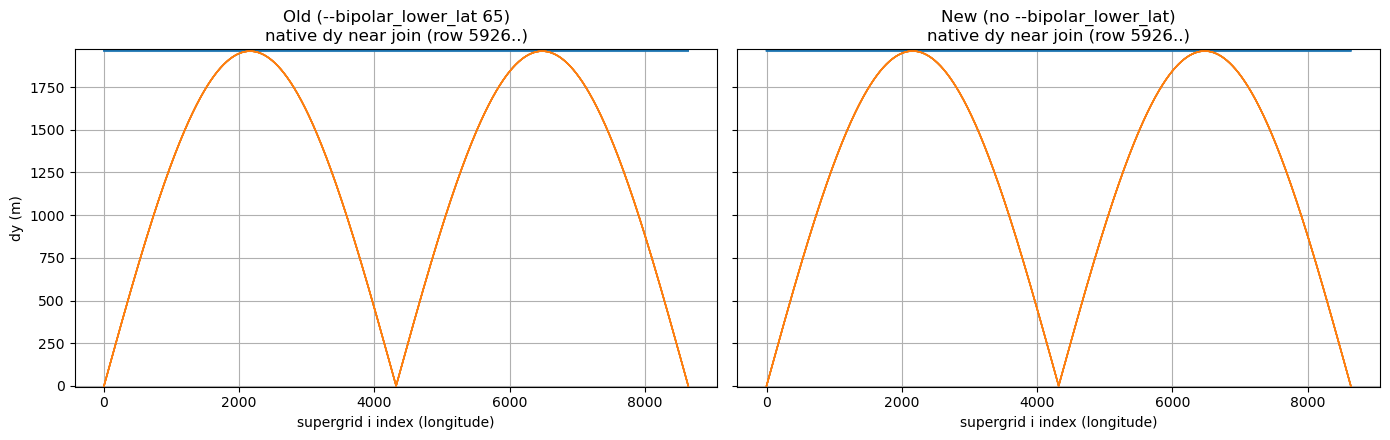

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)

dy_min, dy_max = np.inf, -np.inf
native_dy = {}
for ax, ds, j0, label in [(axes[0], old, j_old, OLD_LABEL), (axes[1], new, j_new, NEW_LABEL)]:
    dys = {}
    for off in offsets:
        dyk = ds.variables['dy'][(j0 - 1) + off, :]
        dys[off] = dyk
        ax.plot(dyk, color='C0' if off < 0 else ('k' if off == 0 else 'C1'), alpha=0.6, linewidth=1)
        dy_min, dy_max = min(dy_min, dyk.min()), max(dy_max, dyk.max())
    native_dy[label] = dys
    ax.set_title(f'{label}\nnative dy near join (row {j0-1}..)')
    ax.set_xlabel('supergrid i index (longitude)')
    ax.grid()

axes[0].set_ylabel('dy (m)')
for ax in axes:
    ax.set_ylim(dy_min - 5, dy_max + 5)

plt.tight_layout()
savefig(fig, '08_join_native_dy.png')
plt.show()


### Native dy as a 2D image, matched colour limits

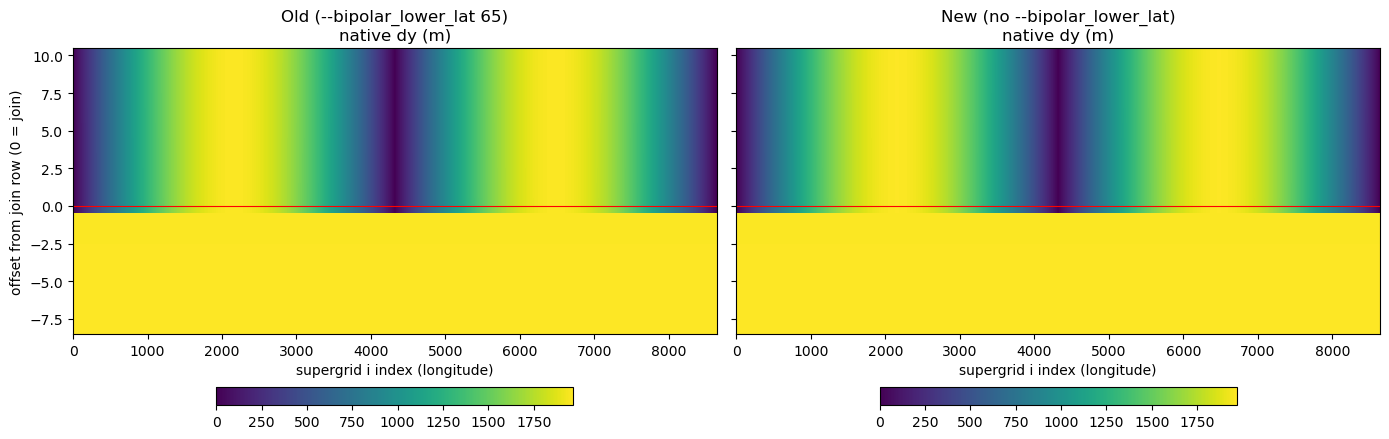

In [17]:
dy_img_old = np.array([native_dy[OLD_LABEL][off] for off in offsets])
dy_img_new = np.array([native_dy[NEW_LABEL][off] for off in offsets])
dy_img_vmin = min(dy_img_old.min(), dy_img_new.min())
dy_img_vmax = max(dy_img_old.max(), dy_img_new.max())

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)
for ax, img, label in [(axes[0], dy_img_old, OLD_LABEL), (axes[1], dy_img_new, NEW_LABEL)]:
    im = ax.pcolormesh(np.arange(img.shape[1]), offsets, img, vmin=dy_img_vmin, vmax=dy_img_vmax,
                        cmap='viridis', shading='auto')
    ax.axhline(0, color='r', linewidth=0.8)
    ax.set_title(f'{label}\nnative dy (m)')
    ax.set_xlabel('supergrid i index (longitude)')
    fig.colorbar(im, ax=ax, orientation='horizontal', fraction=0.05, pad=0.15)

axes[0].set_ylabel('offset from join row (0 = join)')
plt.tight_layout()
savefig(fig, '08b_join_native_dy_2D.png')
plt.show()
